## Comparison of one seed 

Summary of the changes on this run: 

BELCZYNSKI2010 mass loss prescription 
- weaker winds
- stars stay more massive
- binaries widen less
- more massive BHs
- easier HMXB formation

wolf-rayet-multiplier = 0.1
- WR winds reduced by factor of 10

NJ90 mass loss
- less orbital widening
- closer binaries at collapse

winds VINK2011

kicks reduced: 
- sigma NS: 200 km/s
- sigma BH: 200 km/s
- kick scaling factor: 0.8
- USSN kicks: 20 km/s

kick-direction-power: 0 → -0.5
meaning biased to the orbital plane

additionally the remnant-mass-prescription = MULLERMANDEL is a new addition but I havent changed this yet

In [2]:
import sys
from pathlib import Path
import numpy as np

from postprocessing_biz.spin_calculations import (
    determine_bbh,
    determine_hmxrb,
    spin_param_calculations,
    plot_spin_evolution,
    plot_all_spin_evolution, 
    process_all_detailed_files,
    BHDonorMassSpinPlot,
    process_all_bh_donor_and_spin,
    plot_bh_donor_and_spin,
    plot_multiple_runs_from_dirs,
    get_bbh_hmxrb_overlap
)

import detailed_evolution_plotter.plot_detailed_evolution as plot_detailed_evolution

from matplotlib import pyplot as plt

import h5py as h5
import tempfile

In [2]:
non_detailed_run = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/COMPAS_Output.h5'

overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_run)


Identified 314 BBH systems.
high mass xray binary time for seed 22038 from: 13.613462780245007 to: 13.614519703778006
Observable HMXB (by luminosity) for seed 22038 from 13.614519703778006 to 13.614519703778006 Myr
high mass xray binary time for seed 22110 from: 13.520562843579981 to: 13.521620605076981
Observable HMXB (by luminosity) for seed 22110 from 13.521620605076981 to 13.521620605076981 Myr
high mass xray binary time for seed 22120 from: 12.552490025876999 to: 12.784557999890001
Observable HMXB (by luminosity) for seed 22120 from 12.784557999890001 to 12.784557999890001 Myr
high mass xray binary time for seed 22208 from: 16.53250945864299 to: 16.53425883370499
Observable HMXB (by luminosity) for seed 22208 from 16.53425883370499 to 16.53425883370499 Myr
high mass xray binary time for seed 22227 from: 8.702020289372992 to: 8.702471297841992
Observable HMXB (by luminosity) for seed 22227 from 8.702471297841992 to 8.702471297841992 Myr
high mass xray binary time for seed 22241 fro

/home/elizabeth.morgan/.conda/envs/compas-env/lib/python3.11/site-packages/astropy/units/core.py:568: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)
/home/elizabeth.morgan/.conda/envs/compas-env/lib/python3.11/site-packages/astropy/units/core.py:568: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)


[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0142   50.927     1     36.479     1     53.587  0.000
  3.729814   Stable mass transfer from 1 to 2   44.538     1     34.970     1     57.866  0.000
  4.805120   Star 1: MS->HG                    19.056     2     47.579     1     60.004  0.000
  4.807795   Stable mass transfer from 1 to 2   13.982     7     50.111     1     77.645  0.000
  4.807795   Star 1: HG->HeMS                  13.982     7     50.111     1     77.645  0.000
  5.336372   Star 1: HeMS->HeHG                13.284     8     48.791     1     94.602  0.000
  5.352817   Star 1 undergoes supernova and forms a BH   13.257    14     48.751     1     95.137  0.000
  6.124913   Star 2: MS->HG                    13.257    14     46.125     2    126.661  0.000
  6.125651   Stable mass transfer from 2 to 1   13.257    14     17.023     7     22.637  0.000
  6.125651   Star 2: H

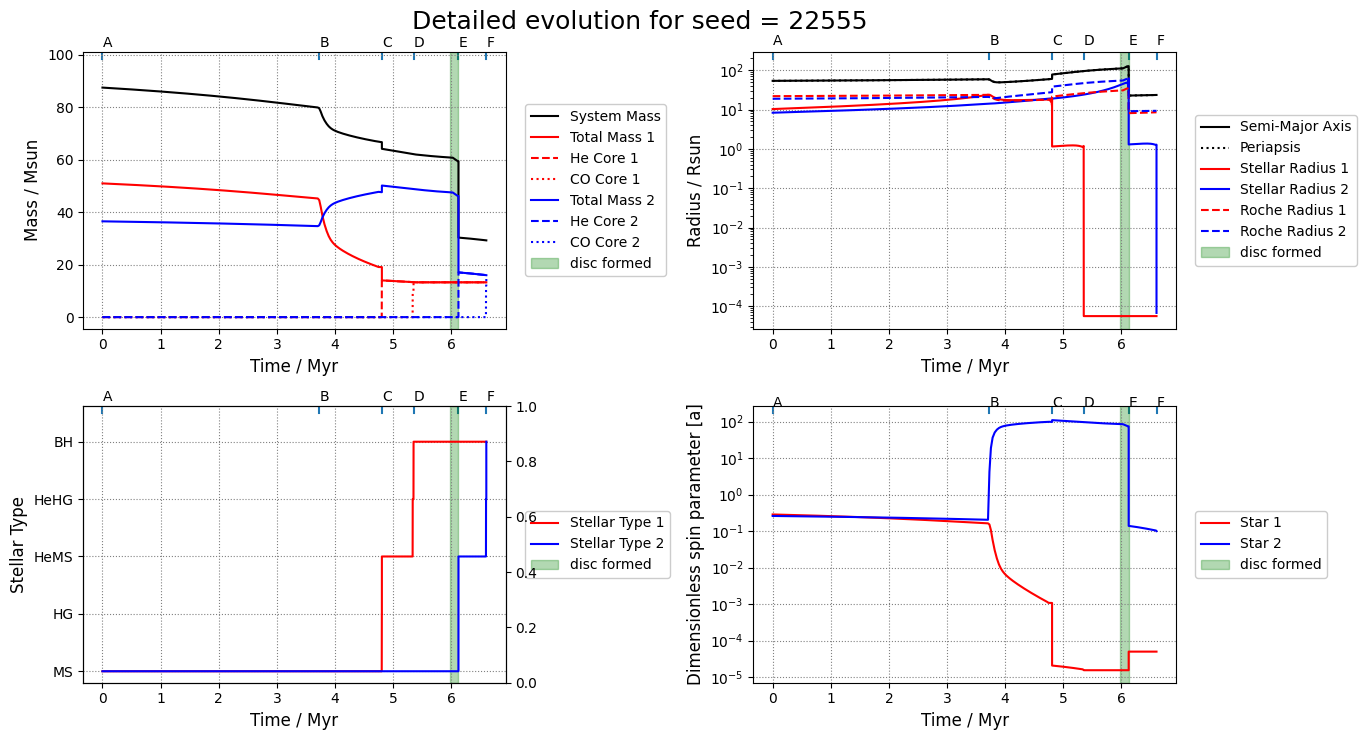

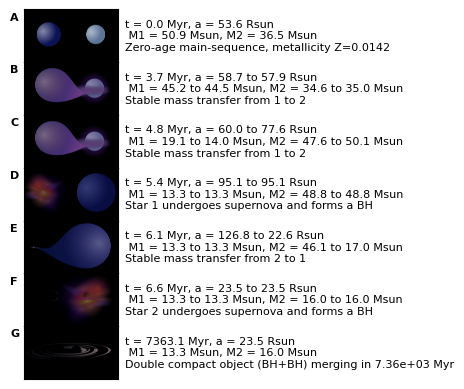

In [3]:
#555: DCO formed: (Main_Sequence_>_0.7 -> Black_Hole) + (Main_Sequence_>_0.7 -> Black_Hole)
#when using a grid file this doesnt frm anymore. when manually specifying the seed it does!
#this has been with a manually set initial rotational frequency of 0.0000002 typical of the VLTFLAMES numbers 
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    disc_start=5.980939535879,
    disc_end=6.125509542871997 #note - this is the RLOF ratio not the disc conditions but just to see
) 

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0142   50.927     1     36.479     1     53.587  0.000
  3.754589   Stable mass transfer from 1 to 2   43.940     1     35.228     1     57.817  0.000
  4.778001   Star 1: MS->HG                    19.372     2     47.371     1     60.688  0.000
  4.780555   Stable mass transfer from 1 to 2   14.052     7     50.026     1     79.245  0.000
  4.780555   Star 1: HG->HeMS                  14.052     7     50.026     1     79.245  0.000
  5.307596   Star 1: HeMS->HeHG                13.347     8     48.721     1     96.251  0.000
  5.322494   Star 1 undergoes supernova and forms a BH   13.323    14     48.685     1     96.741  0.000
  6.131508   Star 2: MS->HG                    13.323    14     46.201     2    126.960  0.000
  6.132246   Stable mass transfer from 2 to 1   13.323    14     17.061     7     23.006  0.000
  6.132246   Star 2: H

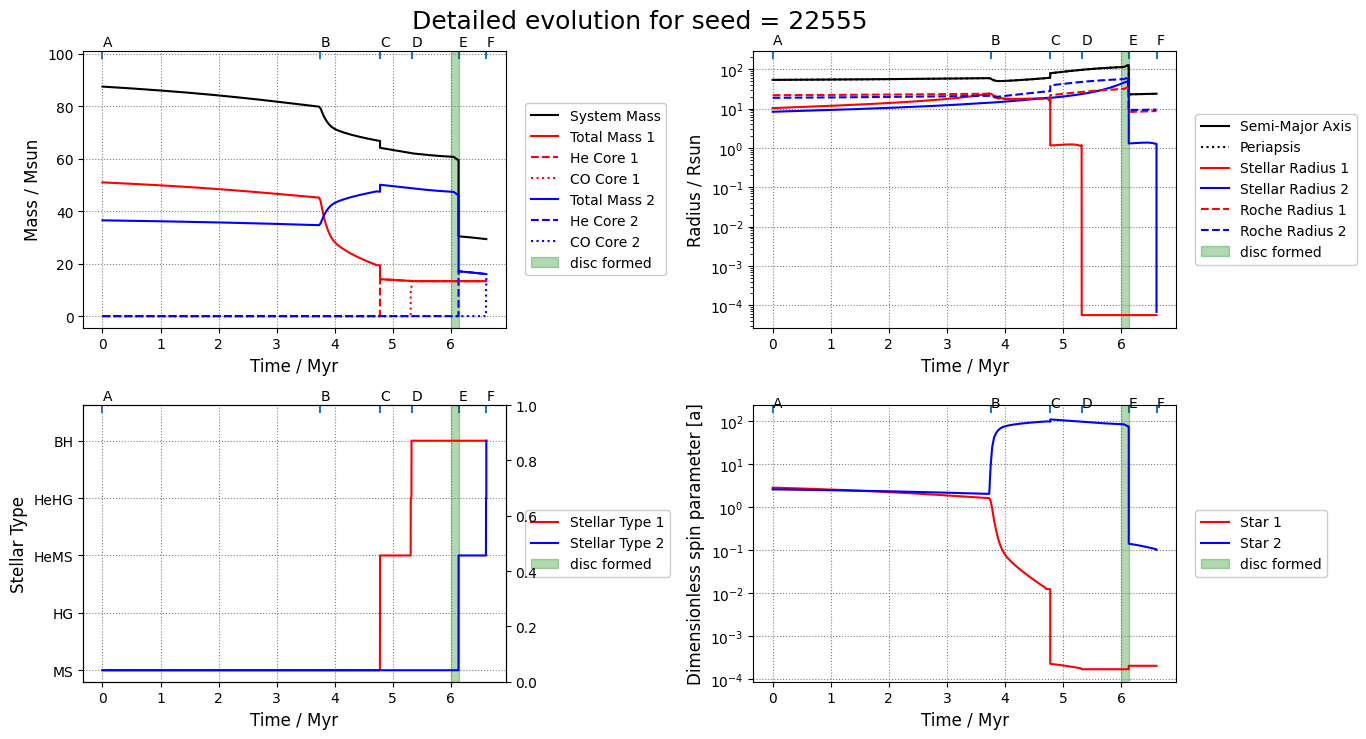

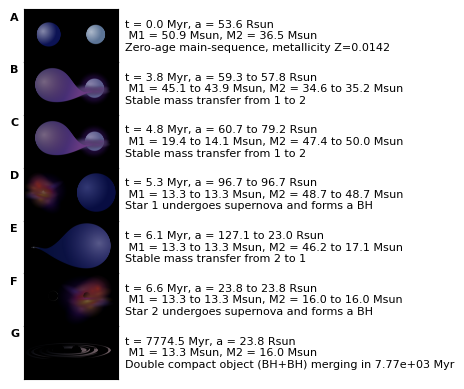

Identified 1 BBH systems.
high mass xray binary time for seed 22555 from: 6.001551106154001 to: 6.132104197202002
Identified 1 HMXRB systems.
--random-seed 22555

Found 1 systems that are BOTH BBH and HMXRB.
--random-seed 22555


In [6]:
#increasing initial angular frequency to 0.000002
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_2/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    disc_start=6.001551106154001,
    disc_end=6.132104197202002 #note - this is the RLOF ratio not the disc conditions but just to see
)

non_detailed_output_2 = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_2/COMPAS_Output.h5'
overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_output_2)

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0142   50.927     1     36.479     1     53.587  0.000
  3.896989   Stable mass transfer from 1 to 2   44.355     1     34.797     1     65.173  0.000
  4.590666   Star 1: MS->HG                    22.768     2     45.494     1     66.608  0.000
  4.592169   Stable mass transfer from 1 to 2   14.453     7     49.649     1     95.727  0.000
  4.592169   Star 1: HG->HeMS                  14.453     7     49.649     1     95.727  0.000
  5.110742   Star 1: HeMS->HeHG                13.706     8     48.442     1    114.192  0.000
  5.125381   Star 1 undergoes supernova and forms a BH   13.680    14     48.407     1    114.746  0.000
  6.185127   Star 2: MS->HG                    13.680    14     45.389     2    157.027  0.000
  6.186177   Stable mass transfer from 2 to 1   13.680    14     16.678     7     34.094  0.000
  6.186177   Star 2: H

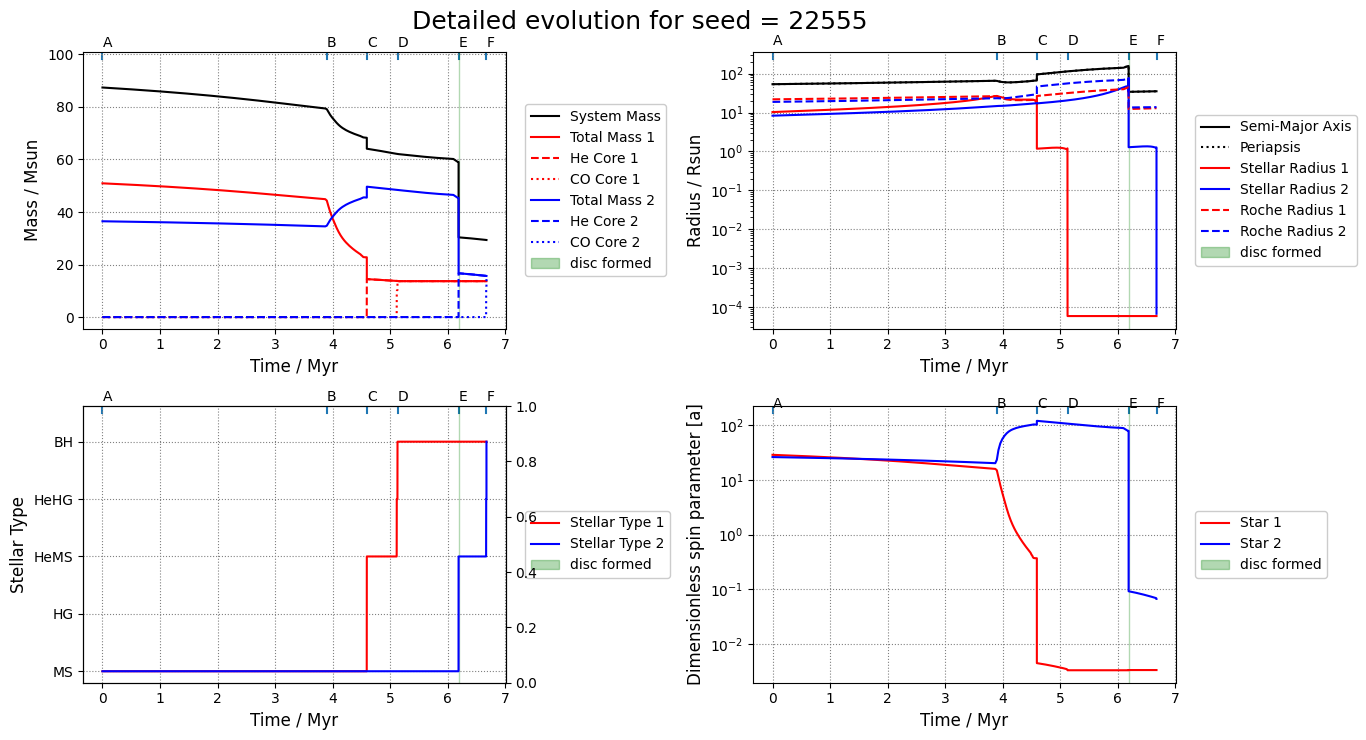

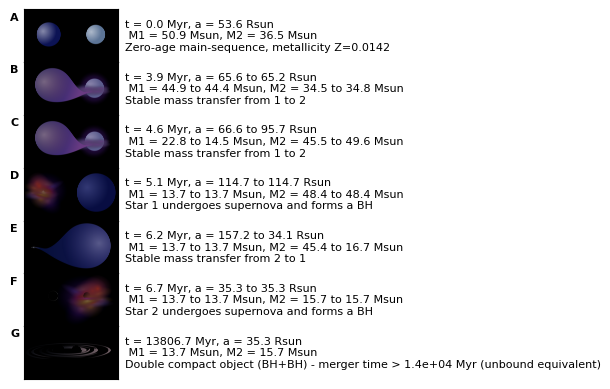

Identified 1 BBH systems.
high mass xray binary time for seed 22555 from: 6.185731906710003 to: 6.186032904395003
Identified 1 HMXRB systems.
--random-seed 22555

Found 1 systems that are BOTH BBH and HMXRB.
--random-seed 22555


In [8]:
#increasing initial angular frequency to 0.00002 - still a BBH but now unbound
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_3/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    disc_start=6.185731906710003,
    disc_end=6.186032904395003 #note - this is the RLOF ratio not the disc conditions but just to see
) 

non_detailed_output_3 = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_3/COMPAS_Output.h5'
overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_output_3)

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0142   50.927     1     36.479     1     53.588  0.000
  4.405066   Star 1: MS->HG                    43.484     2     34.143     1    161.254  0.000
  4.406036   Stable mass transfer from 1 to 2   15.732     7     48.014     1    241.851  0.000
  4.406036   Star 1: HG->HeMS                  15.732     7     48.014     1    241.851  0.000
  4.900105   Star 1: HeMS->HeHG                14.844     8     47.032     1    281.684  0.000
  4.911140   Star 1 undergoes supernova and forms a BH   14.822    14     47.009     1    282.657  0.000
  6.237642   Star 2: MS->HG                    14.822    14     43.948     2    393.386  0.000
  6.239952   Stable mass transfer from 2 to 1   14.822    14     16.043     7    135.268  0.000
  6.239952   Star 2: HG->HeMS                  14.822    14     16.043     7    135.268  0.000
  6.728595   Star 2: He

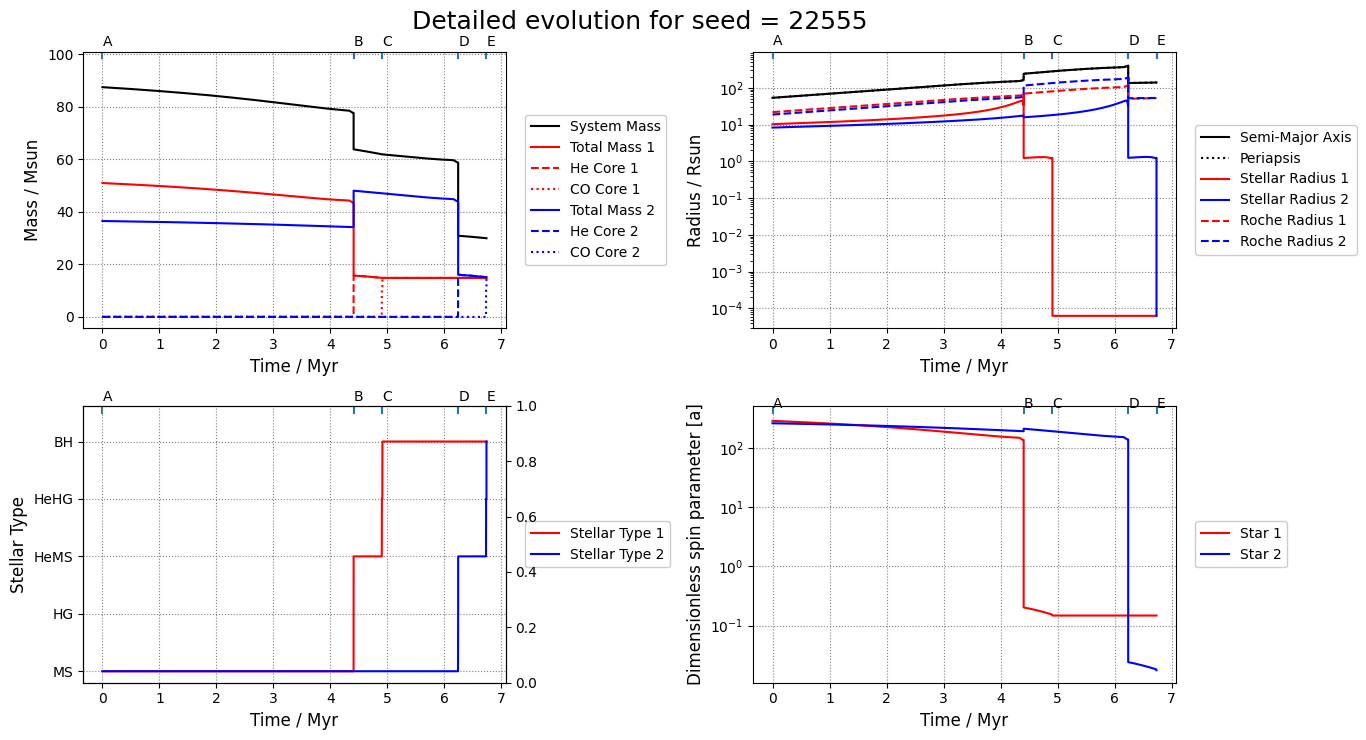

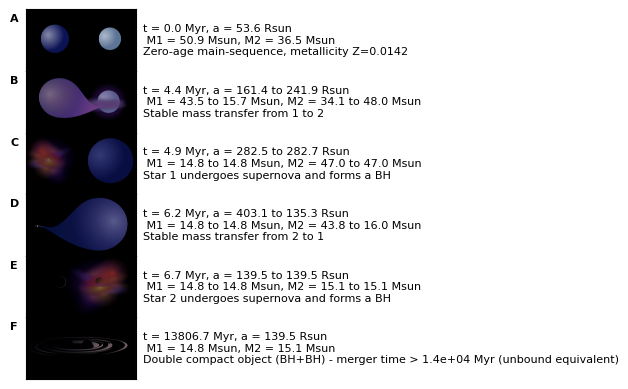

Identified 1 BBH systems.
Identified 0 HMXRB systems.

Found 0 systems that are BOTH BBH and HMXRB.


In [9]:
#increasing initial angular frequency to 0.0002 - this is no longer a hmxrb system 
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_4/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    #disc_start=5.980939535879,
    #disc_end=6.125509542871997 #note - this is the RLOF ratio not the disc conditions but just to see
) 

non_detailed_output_4 = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_4/COMPAS_Output.h5'
overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_output_4)

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0142   50.927     1     36.479     1     53.593  0.000
  4.405066   Star 1: MS->HG                    43.484     2     34.143     1   3257.668  0.000
  4.410275   Star 1: HG->CHeB                  15.986     4     34.139     1   9982.875  0.000
  4.411256   Star 1: CHeB->HeMS                15.986     7     34.138     1   9984.167  0.000
  4.899904   Star 1: HeMS->HeHG                15.071     8     33.815     1   10783.513  0.000
  4.909368   Star 1 undergoes supernova and forms a BH   15.052    14     33.809     1   10799.088  0.000
  5.328362   Star 2: MS->HG                    15.052    14     33.583     2   11235.185  0.000
  5.335388   Star 2: HG->CHeB                  15.052    14     33.509     4   11438.922  0.000
  5.750751   Star 2: CHeB->HeMS                15.052    14     13.237     7   37253.787  0.000
  5.906938   Star 2:

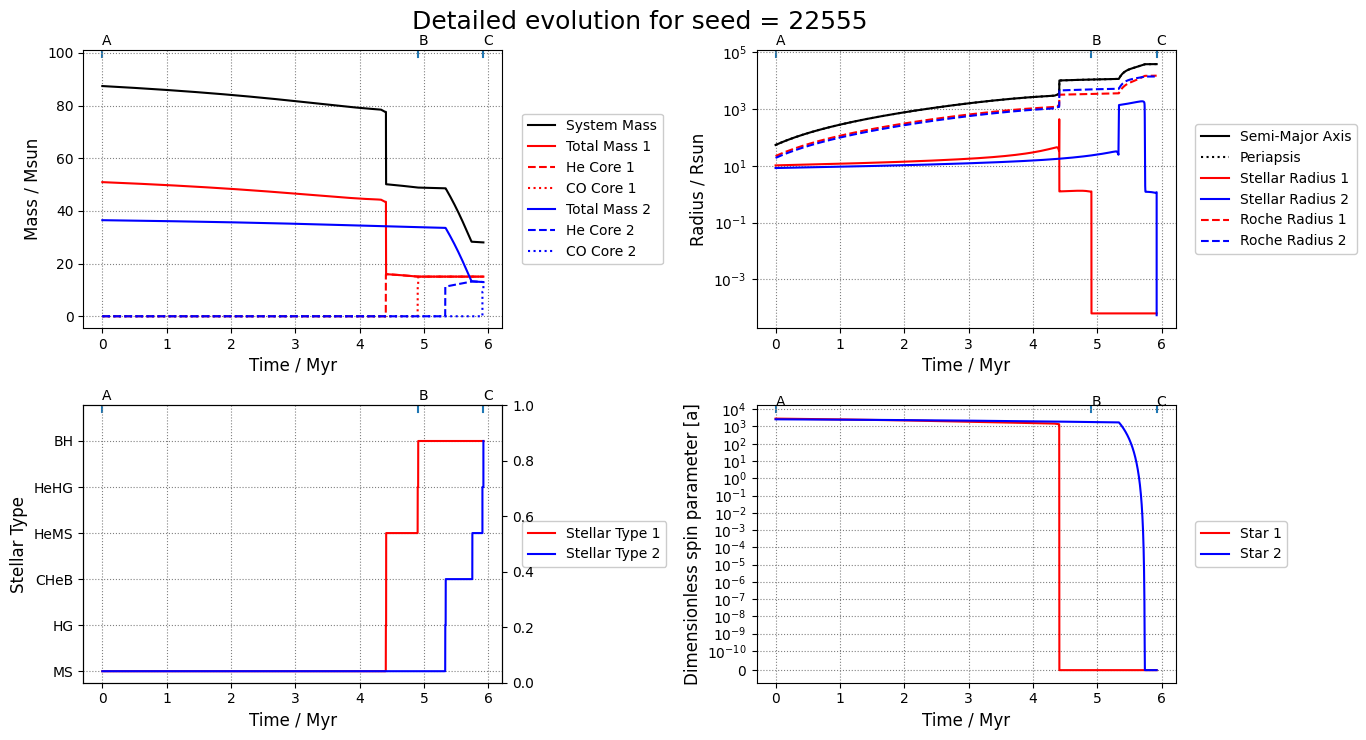

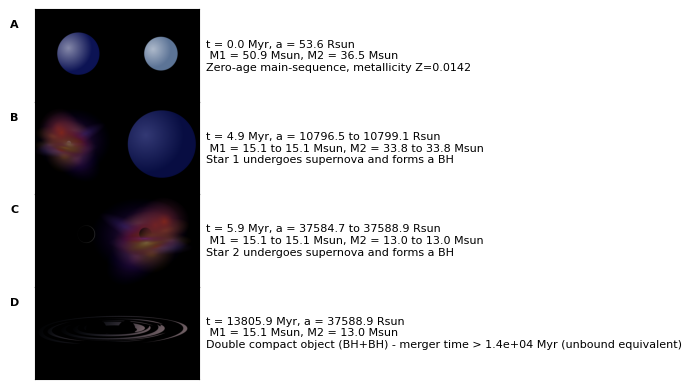

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0142   50.927     1     36.479     1    121.183  0.000
  4.405066   Star 1: MS->HG                    43.484     2     34.143     1   243137843825.751  0.000
  4.410275   Star 1: HG->CHeB                  15.986     4     34.139     1   814482652660.701  0.000
  4.411256   Star 1: CHeB->HeMS                15.986     7     34.138     1   814598090523.670  0.000
  4.899904   Star 1: HeMS->HeHG                15.071     8     33.815     1   884657981936.235  0.000
  4.909368   Star 1 undergoes supernova and forms a BH   15.052    14     33.809     1   886014804851.643  0.000
  5.328362   Star 2: MS->HG                    15.052    14     33.583     2   925118095721.425  0.000
  5.335388   Star 2: HG->CHeB                  15.052    14     33.509     4   943468607008.504  0.000
  5.750751   Star 2: CHeB->HeMS                15.052    14     

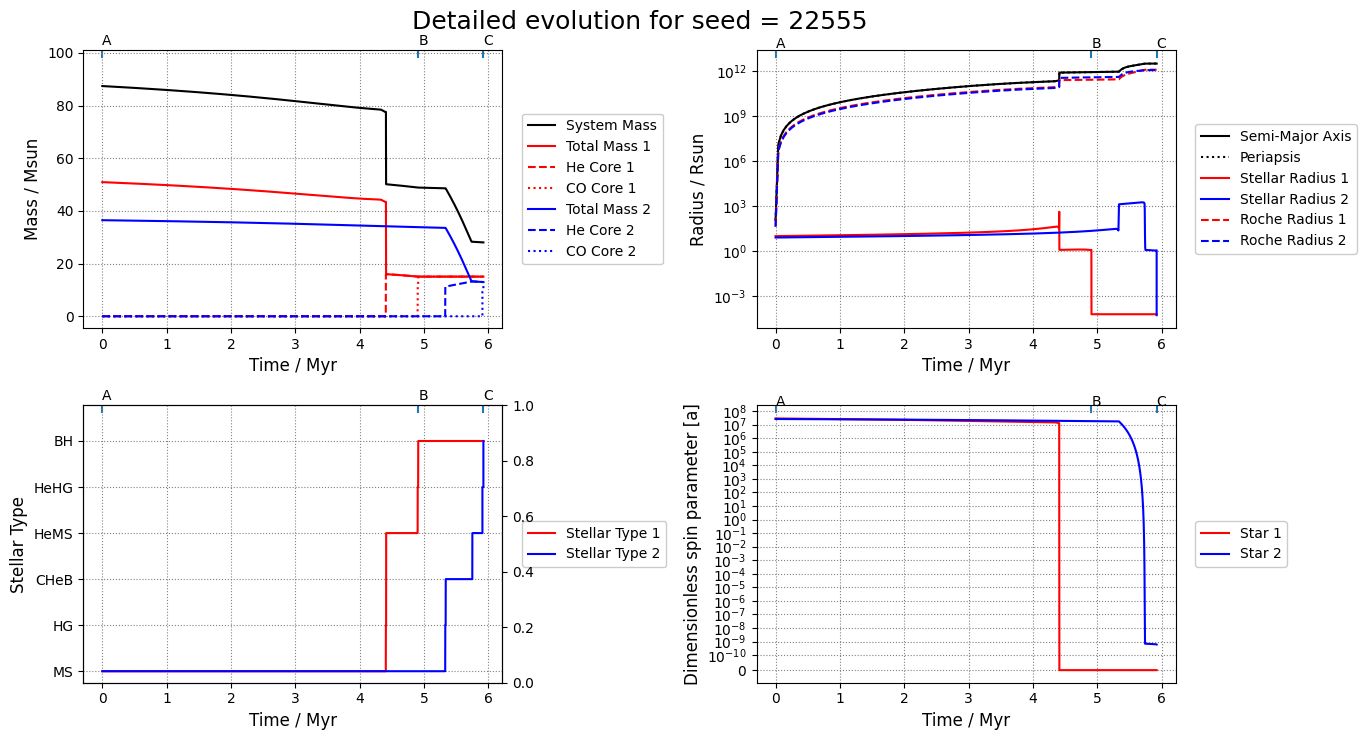

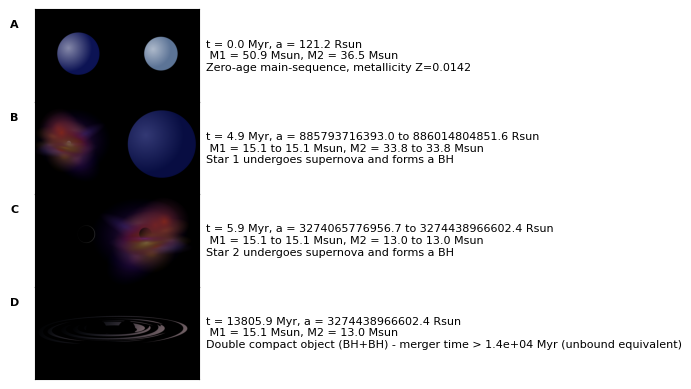

In [13]:
#Increasing angular frequency from here from (0.002 to 20 Hz) follows the same evolution (no hmxrb as no RLOF stage) spin goes to 0 - think this is unphysical for compas? 

#0.002 
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_5/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    #disc_start=5.980939535879,
    #disc_end=6.125509542871997 #note - this is the RLOF ratio not the disc conditions but just to see
) 
# non_detailed_output_5 = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_5/COMPAS_Output.h5'
# overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_output_5) 
#RLOF file doesnt exist

#20
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_9/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    #disc_start=5.980939535879,
    #disc_end=6.125509542871997 #note - this is the RLOF ratio not the disc conditions but just to see
)

# non_detailed_output_9 = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_9/COMPAS_Output.h5'
# overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_output_9)
# RLOF file doesnt exist

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000240   Zero-age main-sequence, metallicity Z=0.0142   10.227     1      4.927     1   1708.329  0.000
 24.207006   Star 1: MS->HG                    10.054     2      4.927     1   1728.473  0.000
 24.271228   Star 1: HG->FGB                   10.052     3      4.927     1   1728.713  0.000
 24.279161   Star 1: FGB->CHeB                 10.050     4      4.927     1   1728.877  0.000
 27.035582   Star 1: CHeB->EAGB                 9.704     5      4.926     1   1770.497  0.000
 27.144676   Star 1 undergoes supernova and forms a NS. Orbit becomes unbound    1.226    13      4.926     1   -4956.162  1.360
106.489369   Star 2: MS->HG                     1.226    13      4.921     2   -4960.990  1.360
106.943507   Star 2: HG->FGB                    1.226    13      4.921     3   -4961.244  1.360
107.179126   Star 2: FGB->CHeB                  1.226    13      4.920     4   -4962.164  1.36

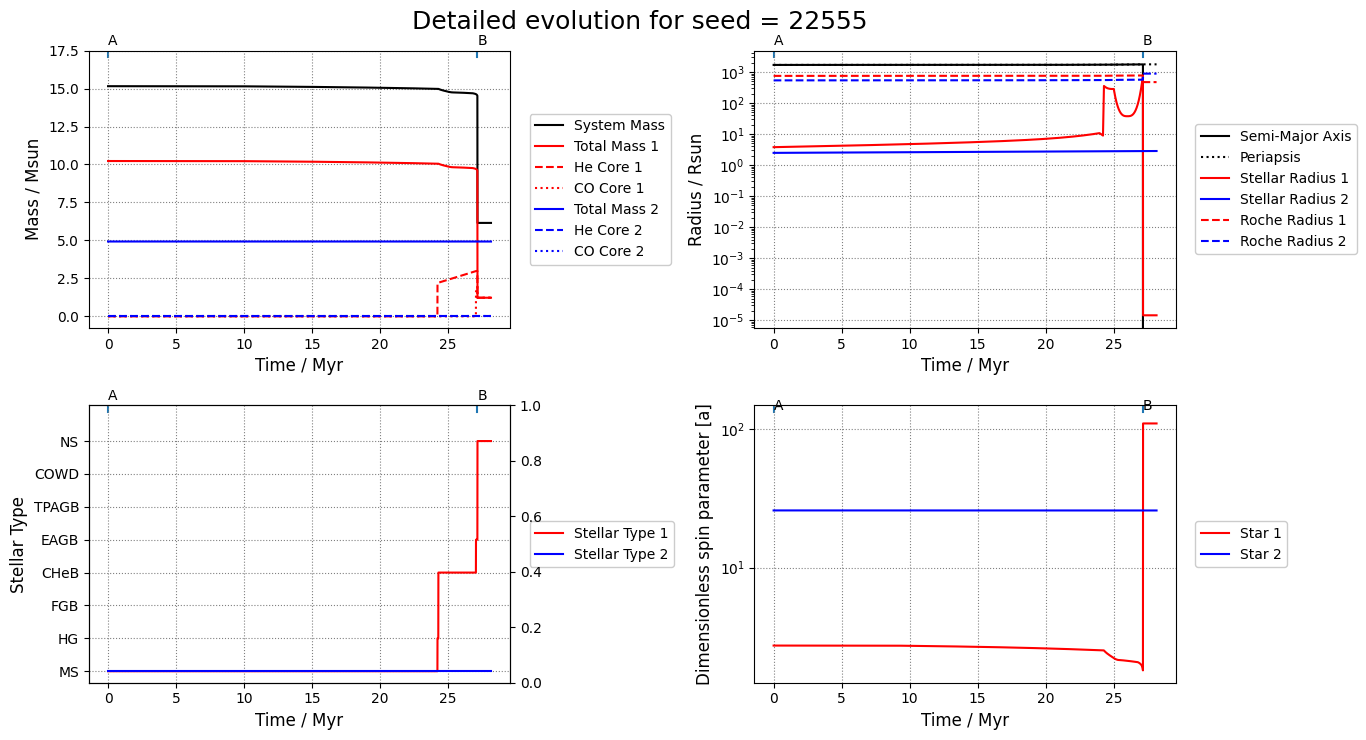

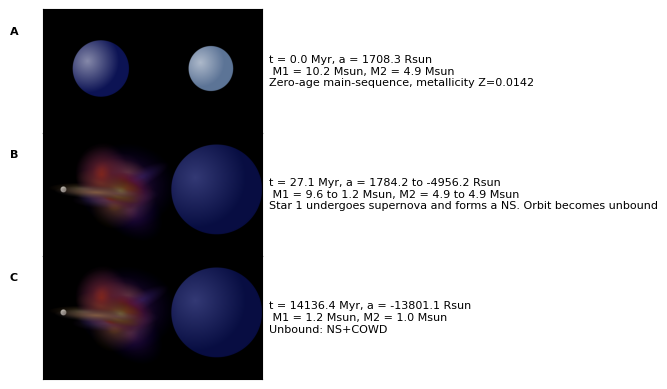

In [17]:
#vltflames survey - doesnt give a BBH, RLOF never occured (file doesnt exist)
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_vlt/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    #disc_start=5.980939535879,
    #disc_end=6.125509542871997 #note - this is the RLOF ratio not the disc conditions but just to see
)

In [18]:
#What was the initial angular frequency of this run which would have made it so different from the ones where I have set the initial frequency? 

#estimate of ang frequency = (ang mom) / 0.075 * Mass * Radius**2 

vltflames_run = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_vlt/Detailed_Output/BSE_Detailed_Output_0.h5' 

Data = h5.File(vltflames_run, 'r')

mass1 = Data['Mass(1)'][()]
mass2 = Data['Mass(2)'][()]
ang1 = Data['Ang_Momentum(1)'][()]
ang2 = Data['Ang_Momentum(2)'][()]
rd1 = Data['Radius(1)'][()]
rd2 = Data['Radius(2)'][()]

ang_freq1 = ang1 / (0.075 * mass1 * (rd1**2) )

print(ang_freq1)

[1.60666640e-02 1.60666640e-02 1.60666640e-02 ... 5.45347868e+09
 5.45347868e+09 5.45347868e+09]


Initial frequency around 10^-2 Hz - so can compare with the run of 0.02 (which also found no RLOF)

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000043   Zero-age main-sequence, metallicity Z=0.0142   50.927     1     36.479     1     53.587  0.000
  3.779644   Stable mass transfer from 1 to 2   43.649     1     35.334     1     58.378  0.000
  4.746932   Star 1: MS->HG                    19.799     2     47.142     1     61.236  0.000
  4.749336   Stable mass transfer from 1 to 2   14.123     7     49.975     1     80.983  0.000
  4.749336   Star 1: HG->HeMS                  14.123     7     49.975     1     80.983  0.000
  5.274848   Star 1: HeMS->HeHG                13.411     8     48.684     1     98.202  0.000
  5.289699   Star 1 undergoes supernova and forms a BH   13.386    14     48.648     1     98.703  0.000
  6.139378   Star 2: MS->HG                    13.386    14     46.167     2    129.558  0.000
  6.140174   Stable mass transfer from 2 to 1   13.386    14     17.048     7     24.020  0.000
  6.140174   Star 2: H

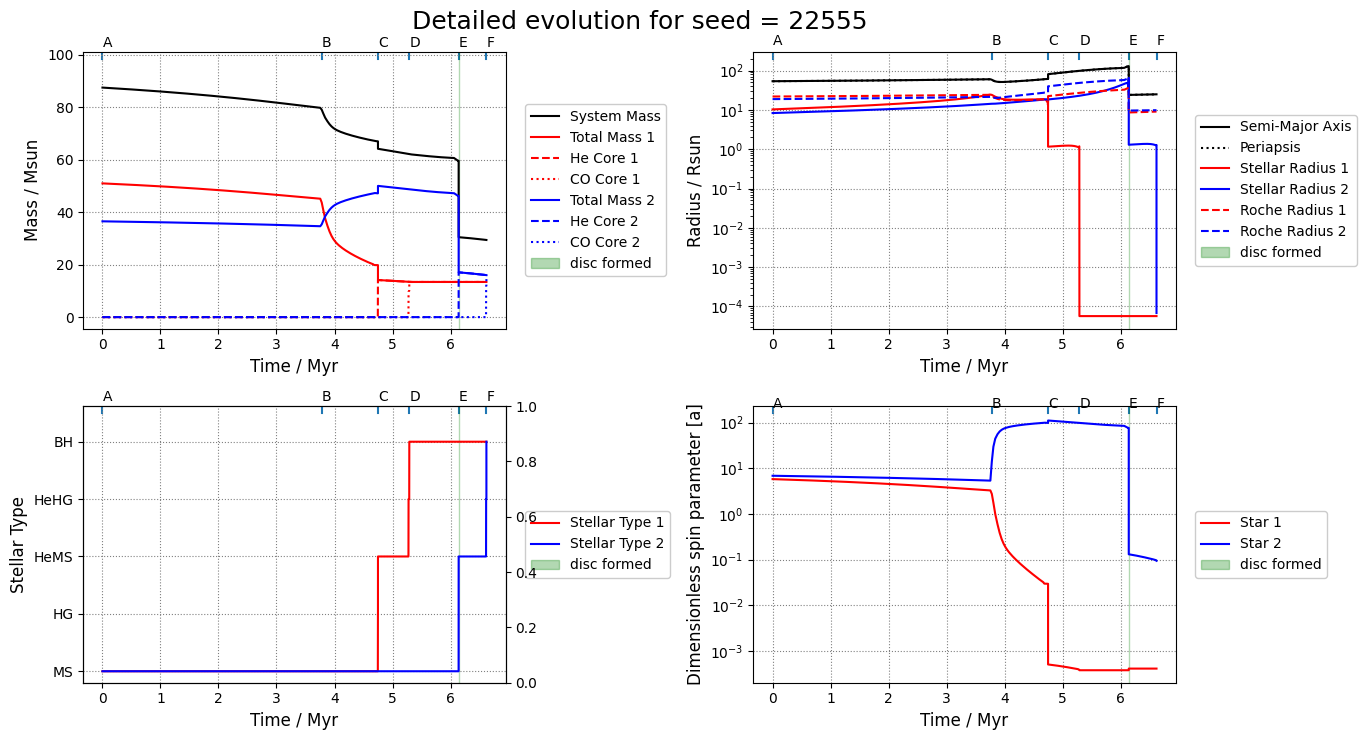

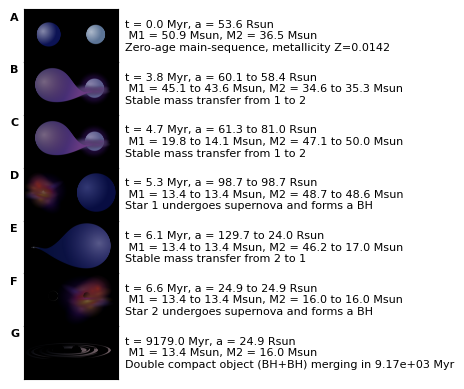

Identified 1 BBH systems.
high mass xray binary time for seed 22555 from: 6.139735651108997 to: 6.140032258765998
Identified 1 HMXRB systems.
--random-seed 22555

Found 1 systems that are BOTH BBH and HMXRB.
--random-seed 22555


In [21]:
#hurley survey - HMXRB - BBH
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_hurley/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    disc_start=6.139735651108997,
    disc_end=6.140032258765998 #note - this is the RLOF ratio not the disc conditions but just to see
)

non_detailed_output_hrl = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_hurley/COMPAS_Output.h5'
overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_output_hrl)

In [24]:
#Again looking at what the initial angular frequency was here to comapre with the set runs 

hurleyflames_run = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/tides_none_macleod_mt_vlt/Detailed_hurley/Detailed_Output/BSE_Detailed_Output_0.h5' 

Data_h = h5.File(hurleyflames_run, 'r')

mass1 = Data_h['Mass(1)'][()]
mass2 = Data_h['Mass(2)'][()]
ang1 = Data_h['Ang_Momentum(1)'][()]
ang2 = Data_h['Ang_Momentum(2)'][()]
rd1 = Data_h['Radius(1)'][()]
rd2 = Data_h['Radius(2)'][()]

ang_freq1 = ang1 / (0.075 * mass1 * (rd1**2) )

print(ang_freq1)


[2.32800830e-02 2.32800830e-02 2.32800830e-02 ... 1.42367369e+04
 1.42367369e+04 1.42367369e+04]


also 10^-2 ... curious .. 

## Running 10,000 binaries 

run 1 - with vltflames survey 

run 2 - with set value 

In [3]:
non_detailed_output_10_vlt = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/10_VLTFLAMES/COMPAS_Output.h5'
overlap_seeds, visible_times = get_bbh_hmxrb_overlap(non_detailed_output_10_vlt)

#need to fix what prints here. 

high mass xray binary time for seed 3210039 from: 5.103369697472008 to: 5.103567505642007
high mass xray binary time for seed 3210060 from: 11.094266705802008 to: 11.28814169821901
Observable HMXB (by luminosity) for seed 3210060 from 11.28814169821901 to 11.28814169821901 Myr
high mass xray binary time for seed 3210080 from: 6.6510033806980005 to: 6.651328987278
high mass xray binary time for seed 3210110 from: 4.927157710096996 to: 4.927696901475776
Observable HMXB (disc formation) for seed 3210110 from 4.927414401475984 to 4.927696901475776 Myr
high mass xray binary time for seed 3210314 from: 6.384864423283999 to: 6.531234197676001
high mass xray binary time for seed 3210416 from: 8.615866630194999 to: 8.951959450754996
Observable HMXB (by luminosity) for seed 3210416 from 8.951959450754996 to 8.951959450754996 Myr
high mass xray binary time for seed 3210442 from: 24.545740360730047 to: 24.549150304415047
Observable HMXB (by luminosity) for seed 3210442 from 24.549150304415047 to 2

/home/elizabeth.morgan/.conda/envs/compas-env/lib/python3.11/site-packages/astropy/units/core.py:568: RuntimeWarning: overflow encountered in multiply
  return lambda val: scale * _condition_arg(val)


high mass xray binary time for seed 3212779 from: 13.522342780289996 to: 13.523664384538995
Observable HMXB (by luminosity) for seed 3212779 from 13.523664384538995 to 13.523664384538995 Myr
high mass xray binary time for seed 3212789 from: 5.696194082122001 to: 5.696471832425001
Observable HMXB (disc formation) for seed 3212789 from 5.696471832425001 to 5.696471832425001 Myr
high mass xray binary time for seed 3212877 from: 10.355149233186996 to: 10.355826113957995
Observable HMXB (by luminosity) for seed 3212877 from 10.355826113957995 to 10.355826113957995 Myr
high mass xray binary time for seed 3213013 from: 25.00989386146207 to: 25.014406463134076
Observable HMXB (by luminosity) for seed 3213013 from 25.014406463134076 to 25.014406463134076 Myr
high mass xray binary time for seed 3213022 from: 5.951826522206001 to: 5.952118122174001
Observable HMXB (disc formation) for seed 3213022 from 5.952118122174001 to 5.952118122174001 Myr
high mass xray binary time for seed 3213106 from: 16

In [5]:
vlt10_run = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/10_VLTFLAMES/Detailed/Detailed_Output/BSE_Detailed_Output_0.h5' 

Data_h = h5.File(vlt10_run, 'r')

mass1 = Data_h['Mass(1)'][()]
mass2 = Data_h['Mass(2)'][()]
ang1 = Data_h['Ang_Momentum(1)'][()]
ang2 = Data_h['Ang_Momentum(2)'][()]
rd1 = Data_h['Radius(1)'][()]
rd2 = Data_h['Radius(2)'][()]

ang_freq1 = ang1 / (0.075 * mass1 * (rd1**2) )

print(ang_freq1[0])

7.427781224661588e-07


In [7]:
detailed_vlt_10 = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/10_VLTFLAMES/Detailed/COMPAS_Output.h5'
overlap_seeds, visible_times = get_bbh_hmxrb_overlap(detailed_vlt_10)

high mass xray binary time for seed 3210039 from: 5.103369697472008 to: 5.103567505642007
high mass xray binary time for seed 3210080 from: 6.6510033806980005 to: 6.651328987278
high mass xray binary time for seed 3210110 from: 4.927157710096996 to: 4.927696901475776
Observable HMXB (disc formation) for seed 3210110 from 4.927414401475984 to 4.927696901475776 Myr
high mass xray binary time for seed 3210314 from: 6.384864423283999 to: 6.531234197676001
high mass xray binary time for seed 3210887 from: 5.122000779710998 to: 5.1226390893780005
Observable HMXB (disc formation) for seed 3210887 from 5.122196247056999 to 5.1226390893780005 Myr
high mass xray binary time for seed 3210921 from: 27.224648261614085 to: 29.10184975320107
high mass xray binary time for seed 3210928 from: 7.3321438781219985 to: 7.3325121286089985
high mass xray binary time for seed 3210973 from: 7.149995464997999 to: 7.150278539568999
high mass xray binary time for seed 3210992 from: 5.621430806183001 to: 5.6216474

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000037   Zero-age main-sequence, metallicity Z=0.0142   59.856     1     56.645     1     69.343  0.000
  3.649885   Stable mass transfer from 1 to 2   50.832     1     49.067     1     81.193  0.000
  4.226384   Star 1: MS->HG                    27.901     2     60.362     1     83.822  0.000
  4.227233   Stable mass transfer from 1 to 2   17.313     7     65.653     1    122.000  0.000
  4.227233   Star 1: HG->HeMS                  17.313     7     65.653     1    122.000  0.000
  4.695469   Star 1: HeMS->HeHG                16.241     8     63.227     1    156.999  0.000
  4.703085   Star 1 undergoes supernova and forms a BH   16.223    14     63.196     1    157.473  0.000
  5.102783   Star 2: MS->HG                    16.223    14     58.205     2    223.198  0.000
  5.103679   Stable mass transfer from 2 to 1   16.223    14     23.343     7     35.689  0.000
  5.103679   Star 2: H

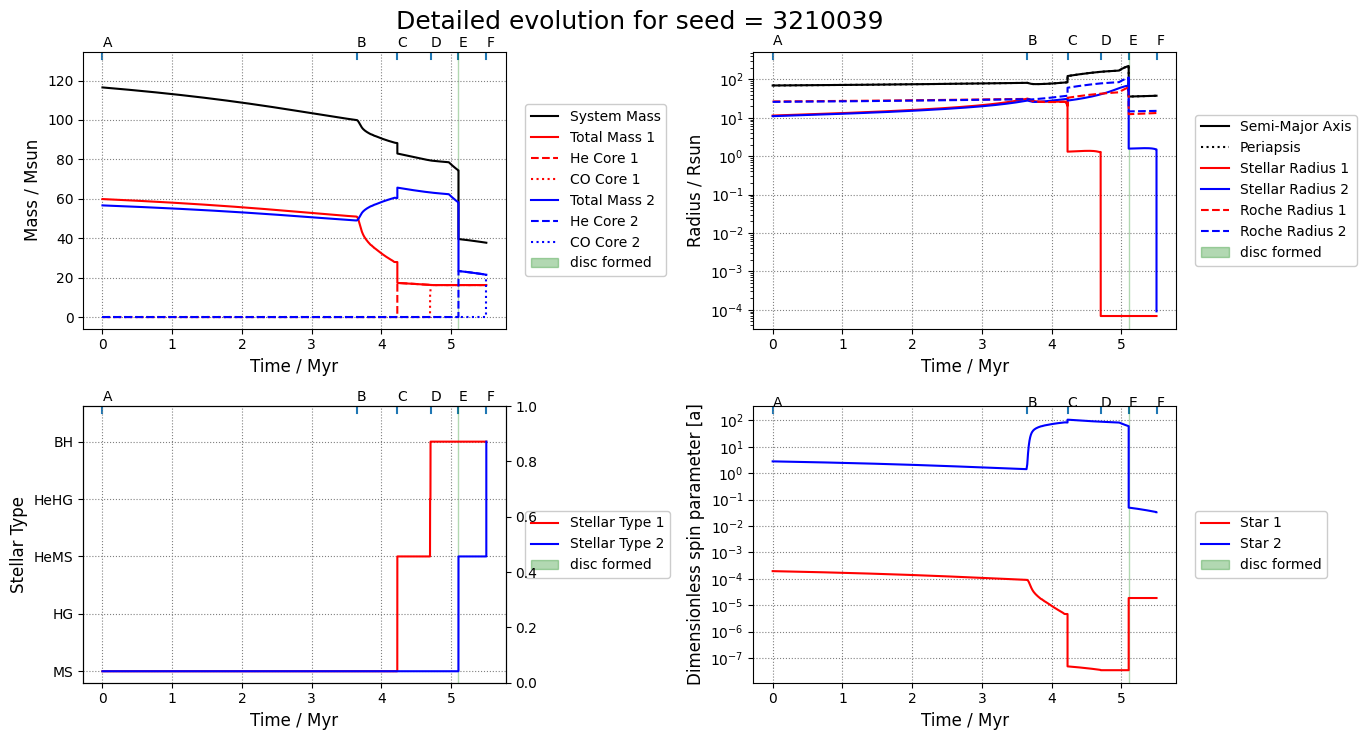

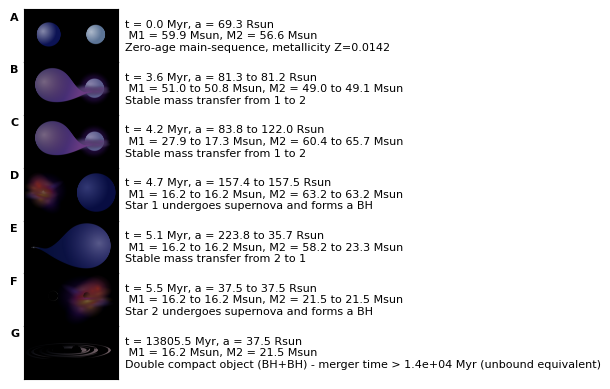

In [9]:
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/10_VLTFLAMES/Detailed/Detailed_Output/BSE_Detailed_Output_0.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    disc_start=5.103369697472008,
    disc_end=5.103567505642007 #note - this is the RLOF ratio not the disc conditions but just to see
)

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000015   Zero-age main-sequence, metallicity Z=0.0142  106.330     1     60.894     1    124.488  0.000
  3.343946   Stable mass transfer from 1 to 2   73.222     1     52.448     1    179.282  0.000
  3.493347   Star 1: MS->HG                    51.322     2     63.075     1    155.830  0.000
  3.493801   Stable mass transfer from 1 to 2   30.546     7     73.459     1    203.597  0.000
  3.493801   Star 1: HG->HeMS                  30.546     7     73.459     1    203.597  0.000
  3.841229   Star 1: HeMS->HeHG                27.587     8     71.007     1    239.825  0.000
  3.842454   Star 1 undergoes supernova and forms a BH   27.587    14     70.998     1    239.961  0.000
  4.926213   Star 2: MS->HG                    27.587    14     60.303     2    355.574  0.000
  4.929333   Star 2: HG->HeMS                  27.587    14     24.753     7    682.967  0.000
  5.316302   Star 2: He

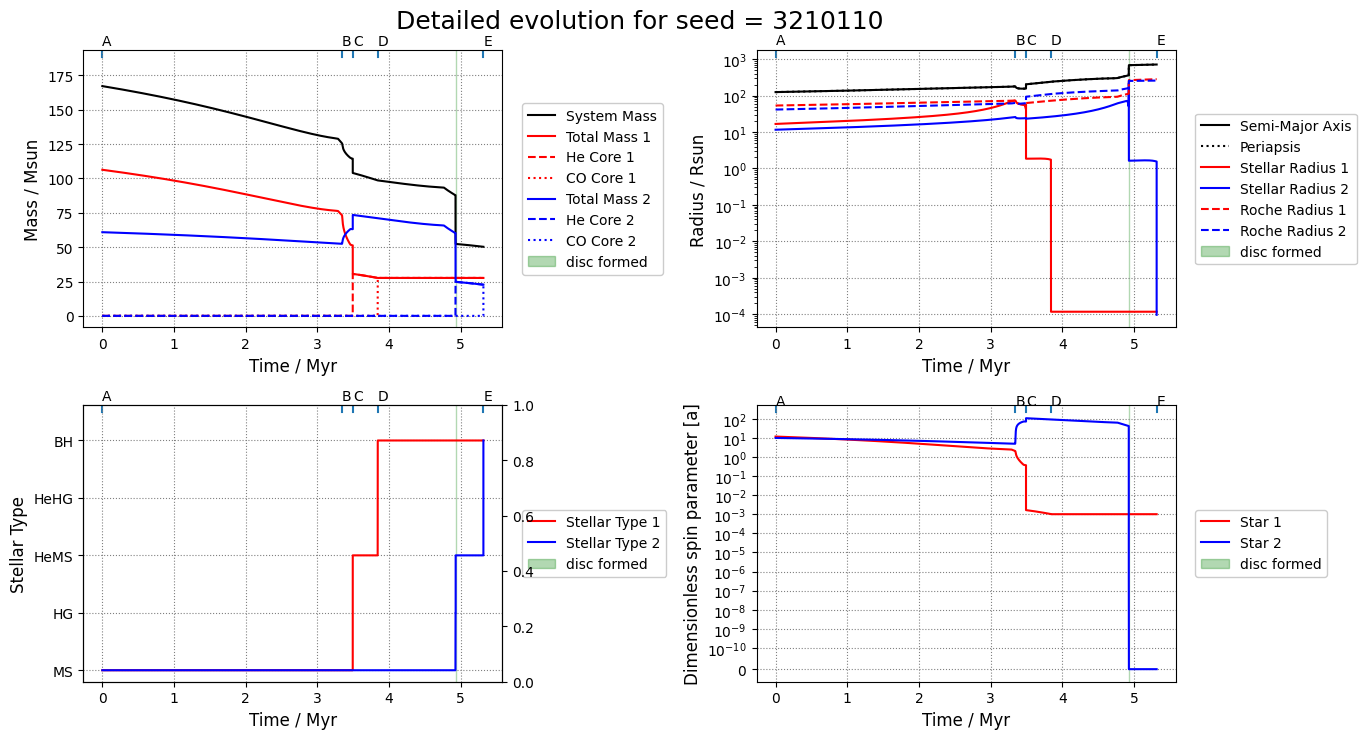

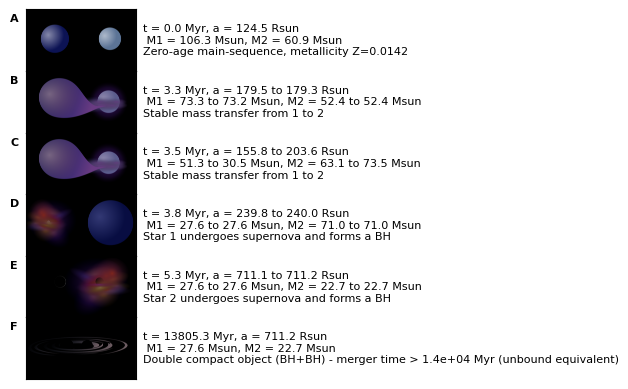

In [10]:
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/10_VLTFLAMES/Detailed/Detailed_Output/BSE_Detailed_Output_2.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    disc_start=4.927414401475984, 
    disc_end=4.927696901475776 
)

[4]
Time (Myr), Event,                            M1 (M_o), type1, M2 (M_o), type2, a (R_o),   e
  0.000014   Zero-age main-sequence, metallicity Z=0.0142  114.145     1     53.333     1    145.308  0.000
  3.393700   Stable mass transfer from 1 to 2   70.312     1     47.438     1    207.518  0.000
  3.436789   Star 1: MS->HG                    61.992     2     51.133     1    188.637  0.000
  3.437175   Stable mass transfer from 1 to 2   29.684     7     67.282     1    224.067  0.000
  3.437175   Star 1: HG->HeMS                  29.684     7     67.282     1    224.067  0.000
  3.789694   Star 1: HeMS->HeHG                26.862     8     65.446     1    255.455  0.000
  3.790932   Star 1 undergoes supernova and forms a BH   26.862    14     65.439     1    255.575  0.000
  5.120926   Star 2: MS->HG                    26.862    14     56.645     2    360.634  0.000
  5.124324   Star 2: HG->HeMS                  26.862    14     22.764     7    700.971  0.000
  5.528566   Star 2: He

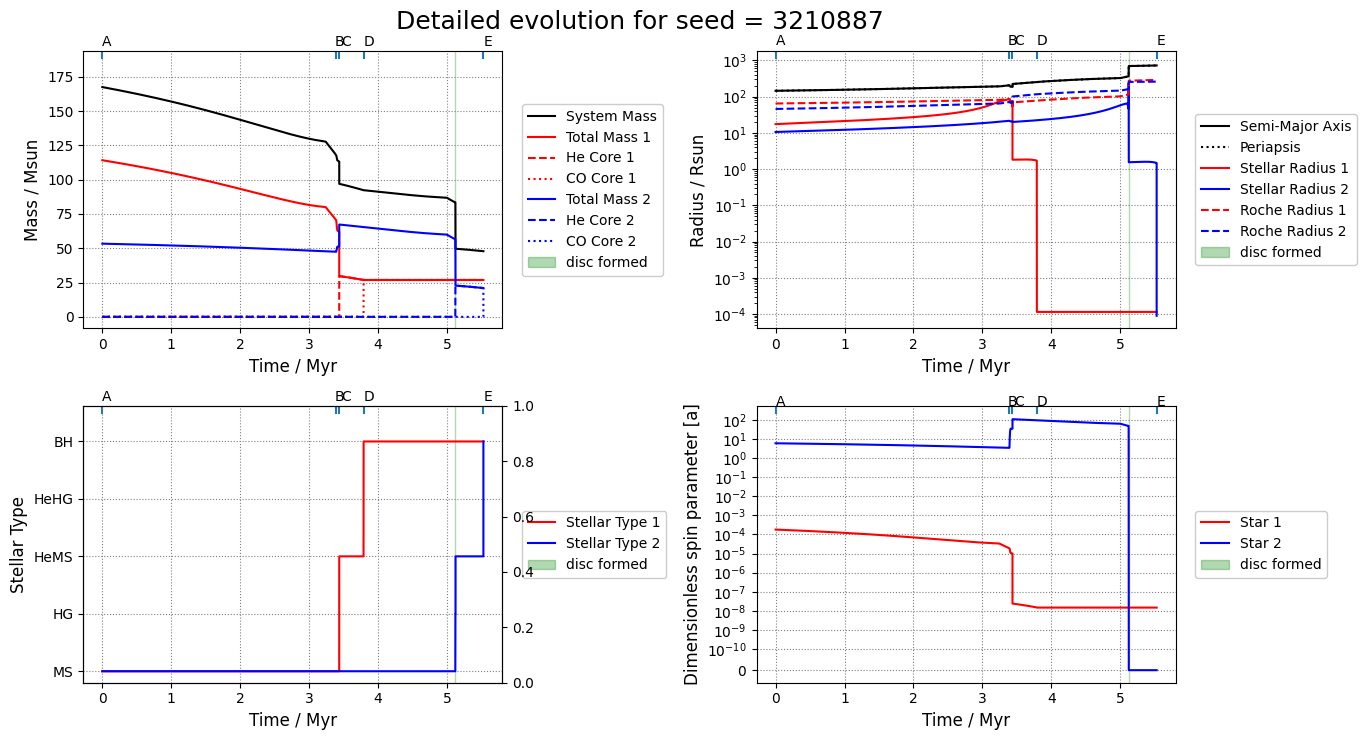

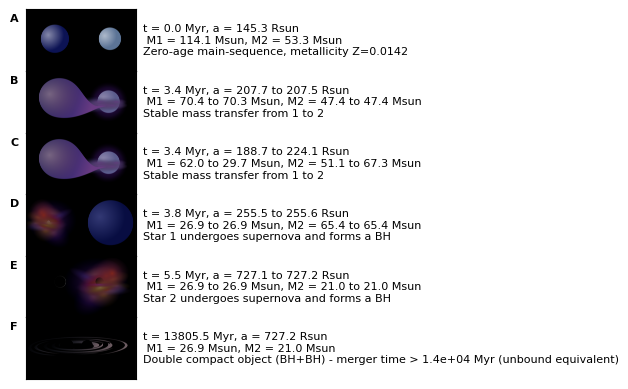

In [11]:
detailed_spin = '/home/elizabeth.morgan/COMPAS/compas_python_utils/preprocessing/outputs/bbhandhmxrb/10_VLTFLAMES/Detailed/Detailed_Output/BSE_Detailed_Output_4.h5' 
fig1, fig2, events = plot_detailed_evolution.run_main_plotter(
    detailed_spin,
    outdir="plots",
    show=True,
    show_spin=True,
    use_latex=False, 
    disc_start=5.122196247056999, 
    disc_end=5.1226390893780005 
)

## Run 2 

setting initial rotational frequency to 0.00007 

(100 times more than the VLT surveys)

